In [32]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
plt.rcParams.update({'figure.dpi':100,'font.size':11})
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=['#E74C3C','#3498DB','#E67E22','#9B59B6','#1ABC9C','#27AE60','#F39C12','#2C3E50'])
print('Ready!')

Ready!


## 1. ACDC — Cardiac MRI (8 methods)

In [33]:
df_acdc = pd.read_csv('D:\\Hoc_Tap\\NCKH\\results\\tables\\crc_fs_results.csv')
# Summary from fold results
methods = ['scp','crc','ascp','acrc','compassl','compassj','crcfsl','crcfsj']
names   = ['Split CP','CRC','Adaptive SCP','Adaptive CRC','COMPASS-L','COMPASS-J','CRC-FS-L','CRC-FS-J']
rows = []
for m, n in zip(methods, names):
    cov = df_acdc[f'{m}_covered'].mean()*100
    wid = df_acdc[f'{m}_width'].mean()
    rows.append({'Method':n,'Coverage':cov,'Width':wid})
df_a = pd.DataFrame(rows)
print('ACDC — LV Volume, Target 90%, 5-fold CV')
print(df_a.to_string(index=False))

ACDC — LV Volume, Target 90%, 5-fold CV
      Method  Coverage    Width
    Split CP      91.0 2.348342
         CRC      89.5 2.227539
Adaptive SCP      91.5 2.550842
Adaptive CRC      90.0 2.477821
   COMPASS-L      92.5 3.058831
   COMPASS-J      92.5 3.047446
    CRC-FS-L      92.5 5.543124
    CRC-FS-J      92.5 4.782810


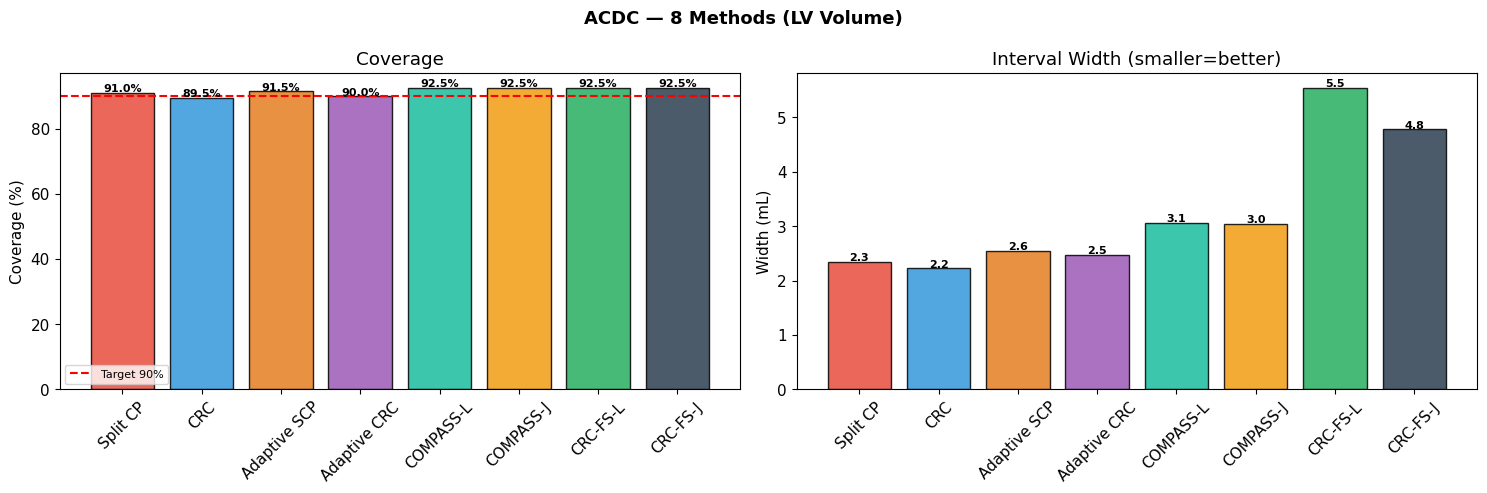

In [34]:
fig, axes = plt.subplots(1,2,figsize=(15,5))
fig.suptitle('ACDC — 8 Methods (LV Volume)', fontsize=13, fontweight='bold')
colors = ['#E74C3C','#3498DB','#E67E22','#9B59B6','#1ABC9C','#F39C12','#27AE60','#2C3E50']

axes[0].bar(df_a['Method'], df_a['Coverage'], color=colors, alpha=0.85, edgecolor='black')
axes[0].axhline(90, color='red', linestyle='--', label='Target 90%')
axes[0].set_ylabel('Coverage (%)'); axes[0].set_title('Coverage'); axes[0].legend(fontsize=8)
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(df_a['Coverage']): axes[0].text(i, v+0.3, f'{v:.1f}%', ha='center', fontsize=8, fontweight='bold')

axes[1].bar(df_a['Method'], df_a['Width'], color=colors, alpha=0.85, edgecolor='black')
axes[1].set_ylabel('Width (mL)'); axes[1].set_title('Interval Width (smaller=better)')
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(df_a['Width']): axes[1].text(i, v+0.02, f'{v:.1f}', ha='center', fontsize=8, fontweight='bold')
plt.tight_layout(); plt.show()

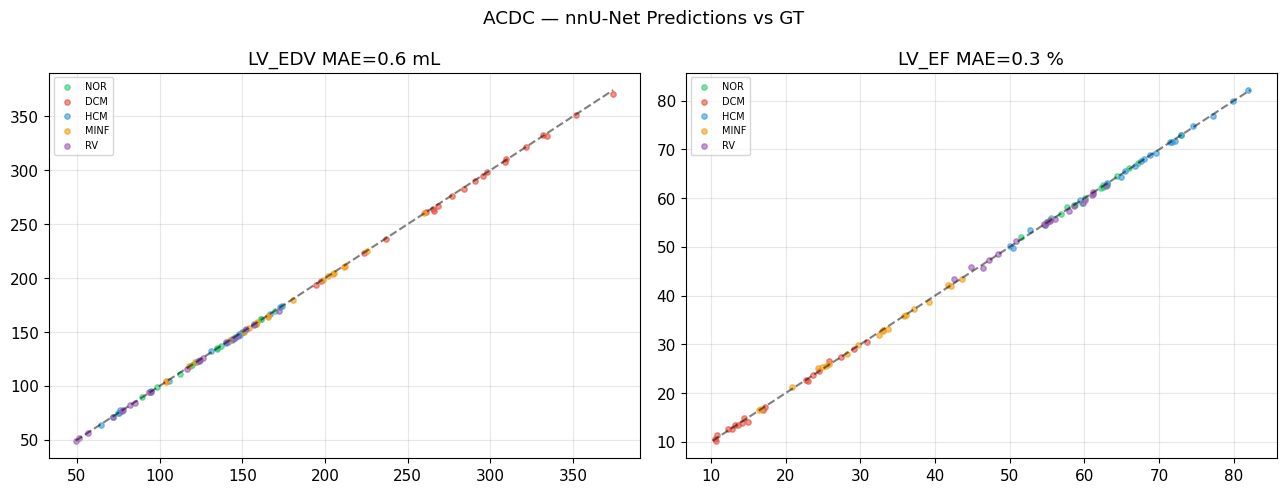

In [35]:
# ACDC metrics scatter
df_m = pd.read_csv('D:\\Hoc_Tap\\NCKH\\results\\tables\\acdc_metrics.csv')
fig, axes = plt.subplots(1,2,figsize=(13,5))
fig.suptitle('ACDC — nnU-Net Predictions vs GT')
groups = ['NOR','DCM','HCM','MINF','RV']
colors_g = ['#2ecc71','#e74c3c','#3498db','#f39c12','#9b59b6']
for ax, m, u in zip(axes, ['LV_EDV','LV_EF'], ['mL','%']):
    gt = df_m[f'{m}_gt']; pred = df_m[f'{m}_pred']
    for g, c in zip(groups, colors_g):
        mask = df_m['group']==g
        ax.scatter(gt[mask], pred[mask], c=c, label=g, alpha=0.6, s=15)
    lims = [min(gt.min(),pred.min()), max(gt.max(),pred.max())]
    ax.plot(lims, lims, 'k--', alpha=0.5)
    mae = (pred-gt).abs().mean()
    ax.set_title(f'{m} MAE={mae:.1f} {u}'); ax.legend(fontsize=7); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 2. LiTS — Liver CT (6 methods)

In [36]:
try:
    df_l = pd.read_csv('D:\\Hoc_Tap\\NCKH\\results\\lits_experiment_results.csv')
    print('LiTS — Liver Volume, Target 90%, 5-fold CV')
    print(df_l.to_string(index=False))
except:
    print('Chua co lits_experiment_results.csv — chay: python experiments/run_lits_pipeline.py --experiment')

LiTS — Liver Volume, Target 90%, 5-fold CV
      method  coverage      width  target
    Split CP 92.336182 139.604499    90.0
         CRC 91.566952 123.990923    90.0
Adaptive SCP 92.364672 167.644016    90.0
Adaptive CRC 90.826211 162.061128    90.0
    Split CP 93.188406  25.580382    90.0
         CRC 91.521739  20.301074    90.0
Adaptive SCP 92.391304  21.896885    90.0
Adaptive CRC 89.891304  17.562968    90.0
   COMPASS-L 92.366412 127.135964     NaN
    CRC-FS-L 91.603053 256.304712     NaN


In [37]:
try:
    df_l = pd.read_csv('results/lits_experiment_results.csv')
    fig, axes = plt.subplots(1,2,figsize=(13,5))
    fig.suptitle('LiTS — 6 Methods (Liver Volume)', fontsize=13, fontweight='bold')
    colors_l = ['#E74C3C','#3498DB','#E67E22','#9B59B6','#1ABC9C','#27AE60']
    axes[0].bar(df_l['method'], df_l['coverage'], color=colors_l, alpha=0.85, edgecolor='black')
    axes[0].axhline(90, color='red', linestyle='--', label='Target 90%')
    axes[0].set_ylabel('Coverage (%)'); axes[0].set_title('Coverage'); axes[0].tick_params(axis='x', rotation=45)
    axes[0].legend(fontsize=8)
    for i, v in enumerate(df_l['coverage']): axes[0].text(i, v+0.3, f'{v:.1f}%', ha='center', fontsize=8, fontweight='bold')
    axes[1].bar(df_l['method'], df_l['width'], color=colors_l, alpha=0.85, edgecolor='black')
    axes[1].set_ylabel('Width (mL)'); axes[1].set_title('Interval Width'); axes[1].tick_params(axis='x', rotation=45)
    for i, v in enumerate(df_l['width']): axes[1].text(i, v+max(df_l['width'])*0.02, f'{v:.1f}', ha='center', fontsize=8, fontweight='bold')
    plt.tight_layout(); plt.show()
except: pass

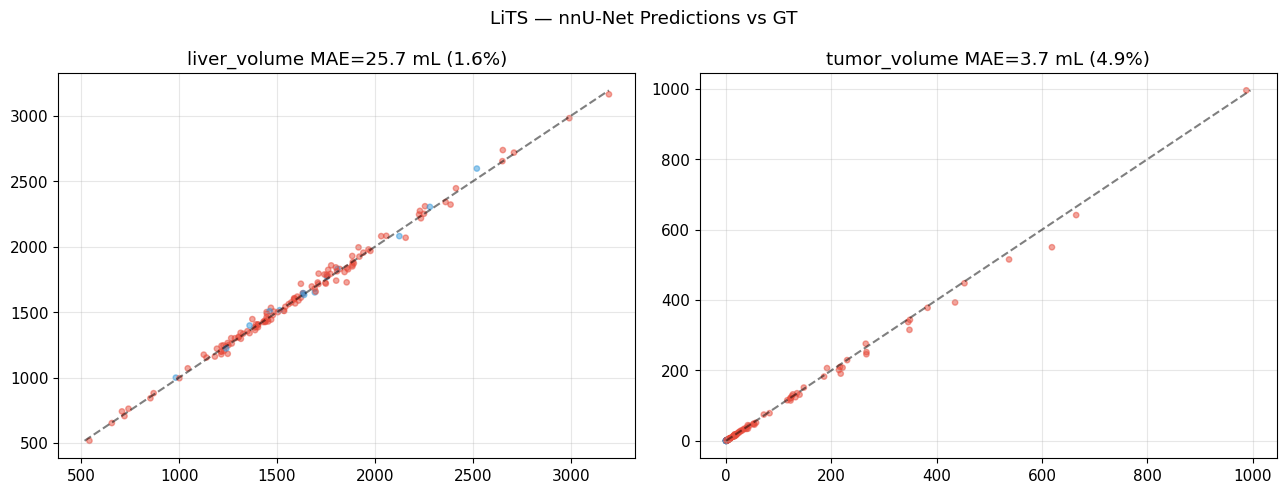

In [38]:
# LiTS metrics scatter
df_m2 = pd.read_csv('D:\\Hoc_Tap\\NCKH\\results\\tables\\lits_metrics.csv')
fig, axes = plt.subplots(1,2,figsize=(13,5))
fig.suptitle('LiTS — nnU-Net Predictions vs GT')
for ax, m, u in zip(axes, ['liver_volume','tumor_volume'], ['mL','mL']):
    gt = df_m2[f'{m}_gt']; pred = df_m2[f'{m}_pred']
    colors = ['#e74c3c' if h else '#3498db' for h in df_m2['has_tumor']]
    ax.scatter(gt, pred, c=colors, alpha=0.5, s=15)
    lims = [min(gt.min(),pred.min()), max(gt.max(),pred.max())]
    ax.plot(lims, lims, 'k--', alpha=0.5)
    mae = (pred-gt).abs().mean()
    ax.set_title(f'{m} MAE={mae:.1f} {u} ({mae/gt.mean()*100:.1f}%)'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 3. So Sanh ACDC vs LiTS

| | ACDC | LiTS |
|---|---|---|
| Modality | Cardiac MRI | Liver CT |
| Patients | 100 (200 frames) | 131 |
| Metrics | LV/RV volume, EF | Liver/Tumor volume |
| Methods | 8 | 6 |
| GPU | 3d_fullres | 3d_lowres |
| MAE liver vol | — | 25.7 mL (1.6%) |
| Best SCP width | 2.35 mL | TBD |